In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

## Load metadata from all models

In [2]:
model_dir = '../models/text/json'
records = []

for fname in sorted(os.listdir(model_dir)):
    if not fname.endswith('_meta.json'):
        continue
    with open(os.path.join(model_dir, fname)) as f:
        records.append(json.load(f))

df = pd.DataFrame(records).sort_values('accuracy', ascending=False).reset_index(drop=True)
df.columns = ['Model', 'Accuracy', 'Macro F1', 'Neg F1', 'Neu F1', 'Pos F1', 'Runtime (s)']
df.round(3)

,Model,Accuracy,Macro F1,Neg F1,Neu F1,Pos F1,Runtime (s)
0,logistic_regression,0.700,0.701,0.683,0.646,0.774,1.350
1,svm,0.682,0.682,0.654,0.620,0.772,3.231
2,naive_bayes,0.672,0.670,0.651,0.615,0.742,0.044
3,mlp_text,0.664,0.666,0.657,0.609,0.733,419.390
4,rnn_text,0.383,0.223,0.128,0.540,0.000,90.378
5,baseline,0.363,0.178,0.000,0.533,0.000,0.001


## Accuracy comparison

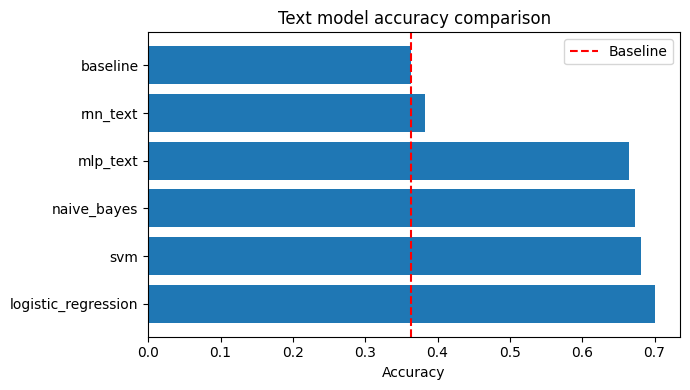

In [3]:
baseline_acc = df.loc[df['Model'] == 'baseline', 'Accuracy'].values[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(df['Model'], df['Accuracy'])
ax.axvline(baseline_acc, color='red', linestyle='--', label='Baseline')
ax.set_xlabel('Accuracy')
ax.set_title('Text model accuracy comparison')
ax.legend()
plt.tight_layout()
plt.show()

## Per-class F1 comparison

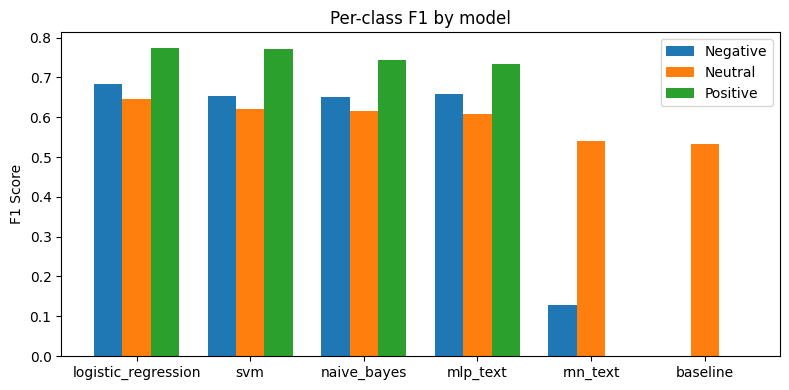

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(df))
width = 0.25
ax.bar([i - width for i in x], df['Neg F1'], width, label='Negative')
ax.bar([i          for i in x], df['Neu F1'], width, label='Neutral')
ax.bar([i + width for i in x], df['Pos F1'], width, label='Positive')
ax.set_xticks(x)
ax.set_xticklabels(df['Model'])
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 by model')
ax.legend()
plt.tight_layout()
plt.show()

## Runtime comparison

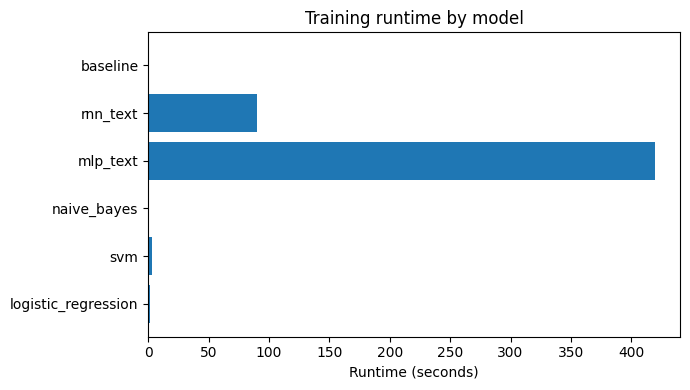

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(df['Model'], df['Runtime (s)'])
ax.set_xlabel('Runtime (seconds)')
ax.set_title('Training runtime by model')
plt.tight_layout()
plt.show()